In [64]:
# ============================================================
# Task 1 : Restaurant Rating Prediction
# ============================================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [65]:
df = pd.read_csv("Dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [66]:
# Shape of Dataset
print("Shape of Dataset:", df.shape)

Shape of Dataset: (9551, 21)


In [67]:
# Display Column Names
print(df.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [68]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [69]:
# Statistical Summary
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## 📌 Observations

- Dataset contains **9551 records** and **21 features**.
- Both numerical and categorical features are present.
- Only the **Cuisines** column contains missing values (9 records).
- The target variable is **Aggregate Rating**, making this a **Regression Problem**.
- Some numerical columns such as **Average Cost for Two** contain possible outliers that require further investigation.

DATA QUALITY CHECK !!

In [70]:
# Missing Values

df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [71]:
# Duplicate Records

df.duplicated().sum()

np.int64(0)

In [72]:
# Missing Values in Percentage

(df.isnull().sum()/len(df))*100

Restaurant ID           0.000000
Restaurant Name         0.000000
Country Code            0.000000
City                    0.000000
Address                 0.000000
Locality                0.000000
Locality Verbose        0.000000
Longitude               0.000000
Latitude                0.000000
Cuisines                0.094231
Average Cost for two    0.000000
Currency                0.000000
Has Table booking       0.000000
Has Online delivery     0.000000
Is delivering now       0.000000
Switch to order menu    0.000000
Price range             0.000000
Aggregate rating        0.000000
Rating color            0.000000
Rating text             0.000000
Votes                   0.000000
dtype: float64

DATA CLEANING START !!

In [73]:
# Remove Missing Values

df = df.dropna()

In [74]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [75]:
df.shape

(9542, 21)

## Data Cleaning

- The dataset initially contained **9 missing values** in the `Cuisines` column.
- Since these represented only **0.094%** of the dataset, the corresponding rows were removed.
- No duplicate records were found.
- The cleaned dataset now contains **9542 records** and **21 features**.

# 📊 Exploratory Data Analysis (EDA)

In this section, we analyze the dataset using visualizations to understand patterns, relationships, and distributions before building the machine learning model.

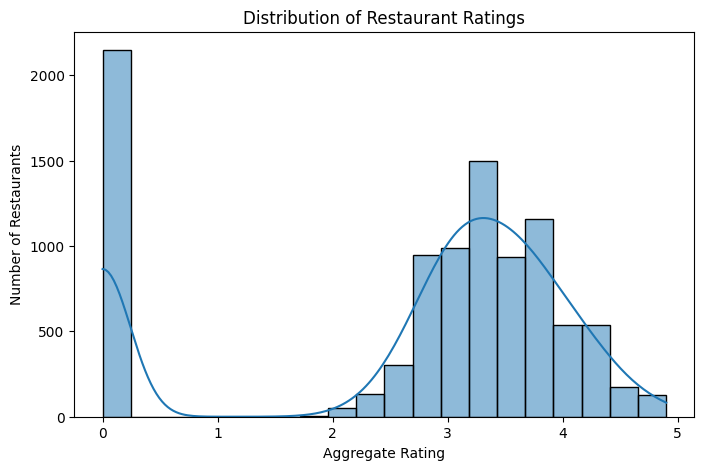

In [76]:
# Distribution of Aggregate Rating

plt.figure(figsize=(8,5))

sns.histplot(df["Aggregate rating"], bins=20, kde=True)

plt.title("Distribution of Restaurant Ratings")

plt.xlabel("Aggregate Rating")

plt.ylabel("Number of Restaurants")

plt.show()

In [77]:
df["Aggregate rating"].describe()

count    9542.000000
mean        2.665238
std         1.516588
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [78]:
df["Aggregate rating"].value_counts().sort_index()

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     495
3.5     480
3.6     458
3.7     427
3.8     399
3.9     332
4.0     266
4.1     274
4.2     221
4.3     174
4.4     143
4.5      95
4.6      78
4.7      41
4.8      25
4.9      61
Name: count, dtype: int64

## 📌 Observations

- The majority of restaurant ratings lie between **3.0 and 4.0**.
- A large number of restaurants have an **Aggregate Rating of 0**, which most likely represents **restaurants that have not yet been rated**.
- Very few restaurants have ratings above **4.5**, indicating that excellent ratings are relatively rare.
- The mean rating is lower than the median because of the large number of unrated restaurants.

In [79]:
df[df["Aggregate rating"] == 0]["Rating text"].value_counts()

Rating text
Not rated    2148
Name: count, dtype: int64

In [80]:
df.groupby("Rating text")["Aggregate rating"].unique()

Rating text
Average      [3.0, 3.2, 3.1, 3.3, 3.4, 2.9, 2.6, 2.8, 2.7, ...
Excellent                            [4.8, 4.5, 4.9, 4.7, 4.6]
Good                                 [3.6, 3.8, 3.7, 3.9, 3.5]
Not rated                                                [0.0]
Poor                       [2.2, 2.4, 2.1, 1.8, 2.0, 2.3, 1.9]
Very Good                            [4.4, 4.0, 4.2, 4.3, 4.1]
Name: Aggregate rating, dtype: object

## 🎯 Target Variable Refinement

The objective of this project is to predict the actual restaurant rating.

After analyzing the dataset, we found that an Aggregate Rating of **0** corresponds to **Not Rated** restaurants rather than poor-quality restaurants.

To train the model only on meaningful customer ratings, these records will be removed before model training.

In [81]:
# Remove Unrated Restaurants

df = df[df["Aggregate rating"] > 0]

In [82]:
df.shape

(7394, 21)

## 🌍 Restaurant Distribution by City

In this section, we analyze which cities have the highest number of restaurants in the dataset.

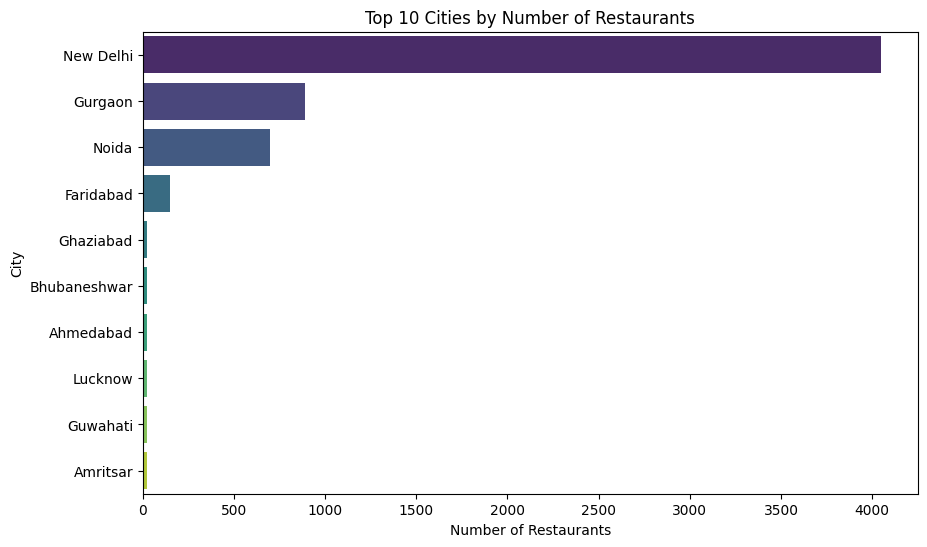

In [83]:
# Top 10 Cities with Maximum Restaurants

top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    hue=top_cities.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

## 📌 Observations

- New Delhi contains the highest number of restaurants in the dataset.
- Gurgaon and Noida are the second and third most represented cities.
- The dataset is highly concentrated in the Delhi-NCR region.
- The city distribution is imbalanced, which may influence model learning if city is used as a feature.

# 💰 Price Range Analysis

This analysis helps us understand whether restaurant price range has any relationship with customer ratings.

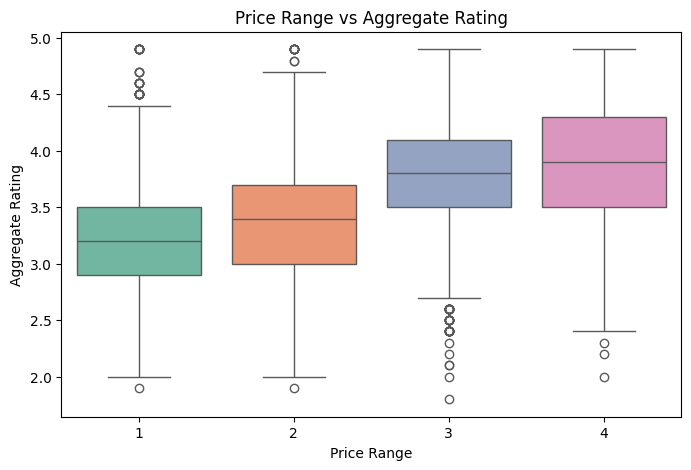

In [84]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Price range",
    y="Aggregate rating",
    data=df,
    palette="Set2"
)

plt.title("Price Range vs Aggregate Rating")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")

plt.show()

## 📌 Observations

- The median aggregate rating increases as the price range increases.
- Higher-priced restaurants generally receive better ratings.
- Some low-priced restaurants also have excellent ratings, showing that affordability does not necessarily mean poor quality.
- A few expensive restaurants have low ratings, indicating that price alone does not guarantee customer satisfaction.

# 🚚 Online Delivery Analysis

This analysis examines whether restaurants offering online delivery tend to receive better customer ratings.

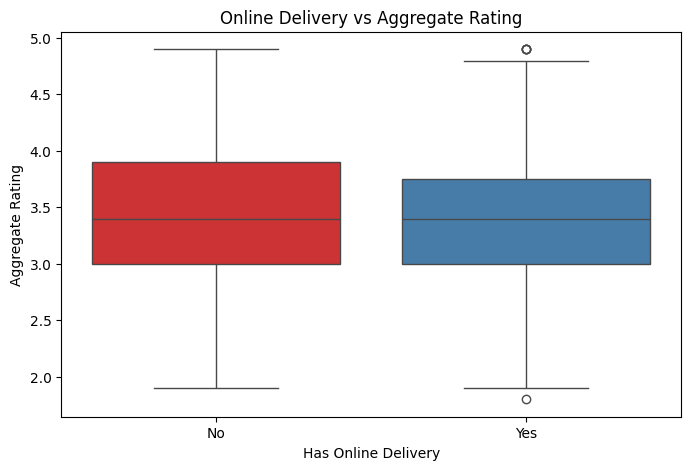

In [85]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Has Online delivery",
    y="Aggregate rating",
    data=df,
    palette="Set1"
)

plt.title("Online Delivery vs Aggregate Rating")
plt.xlabel("Has Online Delivery")
plt.ylabel("Aggregate Rating")

plt.show()

## 📌 Observations

- Restaurants with and without online delivery have very similar median ratings.
- The spread of ratings is comparable in both categories.
- Both groups contain high-rated as well as low-rated restaurants.
- Based on visual analysis, online delivery alone does not appear to have a strong impact on restaurant ratings.

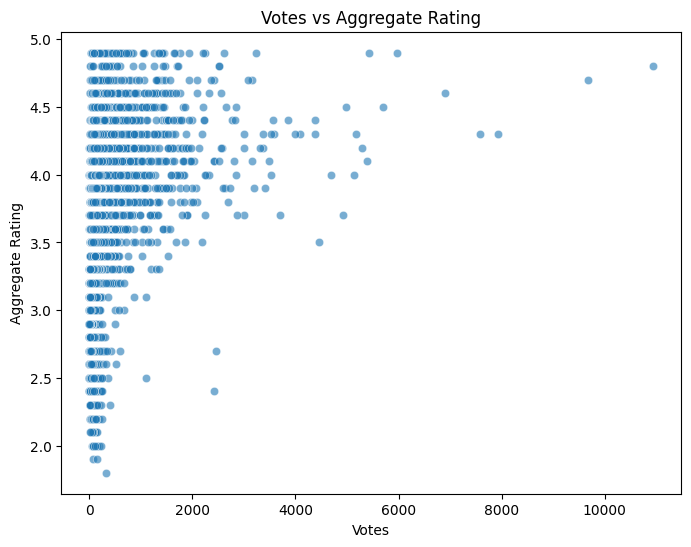

In [86]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df,
    alpha=0.6
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.show()

## 📌 Observations

- Restaurants with a higher number of votes generally tend to have higher aggregate ratings.
- Restaurants with fewer votes show a wider variation in ratings.
- The relationship appears to be **moderately positive**, but not perfectly linear.
- Votes may be an important feature for predicting restaurant ratings.

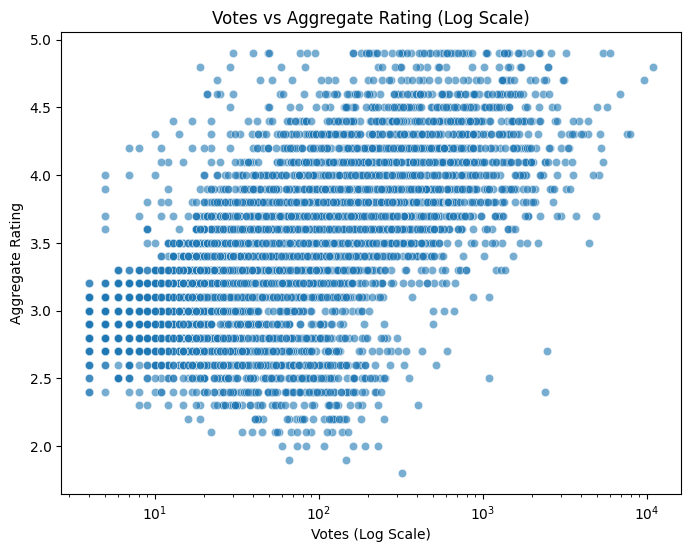

In [87]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Votes",
    y="Aggregate rating",
    data=df,
    alpha=0.6
)

plt.xscale("log")   # 👈 Log scale

plt.title("Votes vs Aggregate Rating (Log Scale)")
plt.xlabel("Votes (Log Scale)")
plt.ylabel("Aggregate Rating")

plt.show()

# 🍽️ Table Booking Analysis

This analysis examines whether restaurants offering table booking tend to receive higher customer ratings.

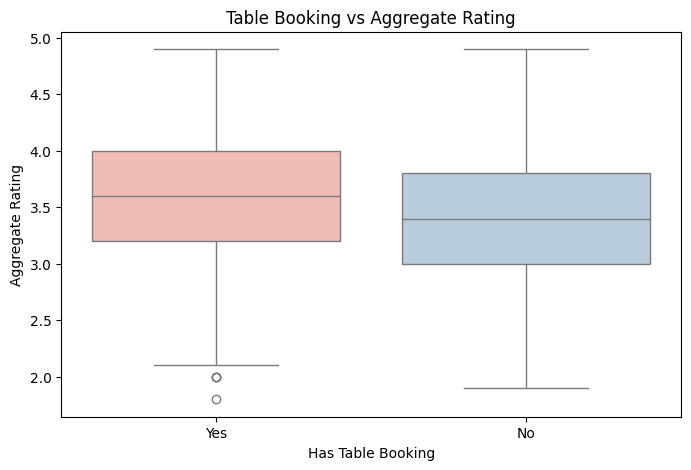

In [88]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Has Table booking",
    y="Aggregate rating",
    data=df,
    palette="Pastel1"
)

plt.title("Table Booking vs Aggregate Rating")
plt.xlabel("Has Table Booking")
plt.ylabel("Aggregate Rating")

plt.show()

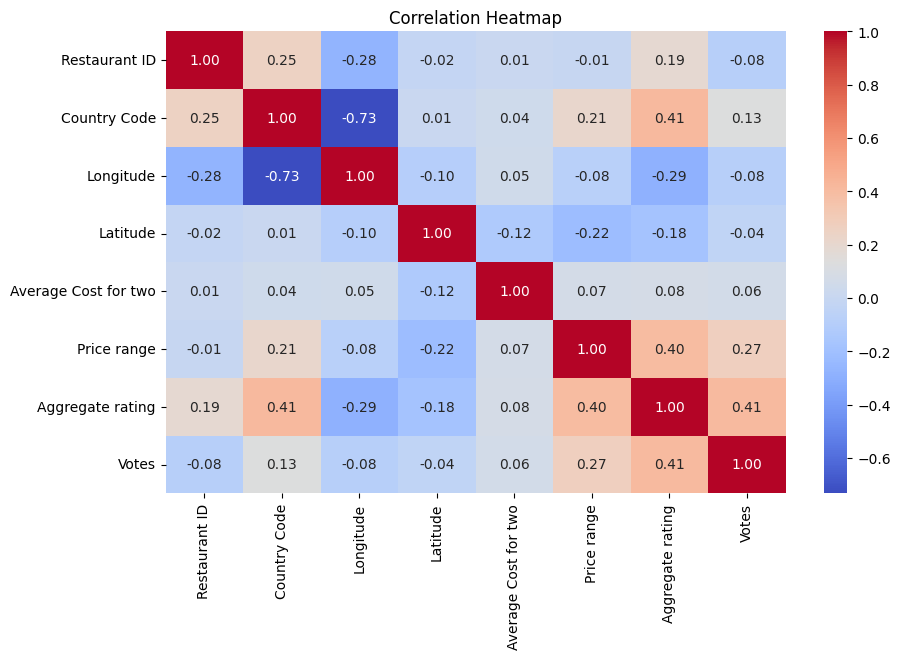

In [89]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ⚙️ Feature Selection

Before training the model, unnecessary columns are removed because they do not contribute meaningful information for predicting restaurant ratings.

In [90]:
# Removing unnecessary columns

columns_to_drop = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color",
    "Rating text"
]

df = df.drop(columns=columns_to_drop)

df.head()

,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,Makati City,121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,314
1,162,Makati City,121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,591
2,162,Mandaluyong City,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,270
3,162,Mandaluyong City,121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,365
4,162,Mandaluyong City,121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,229


In [91]:
df.columns

Index(['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

In [92]:
# Display Categorical Columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['City', 'Cuisines', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu'],
      dtype='object')


In [93]:
binary_columns = [
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Switch to order menu"
]

for col in binary_columns:
    df[col] = df[col].map({"Yes": 1, "No": 0})

df[binary_columns].head()

,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,0,0
4,1,0,0,0


In [94]:
df = df.drop(columns=["Currency", "Cuisines"])

df.head()

,Country Code,City,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes
0,162,Makati City,121.027535,14.565443,1100,1,0,0,0,3,4.8,314
1,162,Makati City,121.014101,14.553708,1200,1,0,0,0,3,4.5,591
2,162,Mandaluyong City,121.056831,14.581404,4000,1,0,0,0,4,4.4,270
3,162,Mandaluyong City,121.056475,14.585318,1500,0,0,0,0,4,4.9,365
4,162,Mandaluyong City,121.057508,14.584450,1500,1,0,0,0,4,4.8,229


In [95]:
df = pd.get_dummies(
    df,
    columns=["City"],
    drop_first=True
)

df.head()

,Country Code,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,...,City_Vernonia,City_Victor Harbor,City_Vineland Station,City_Vizag,City_Waterloo,City_Weirton,City_Wellington City,City_Winchester Bay,City_Yorkton,City_��stanbul
0,162,121.027535,14.565443,1100,1,0,0,0,3,4.8,...,False,False,False,False,False,False,False,False,False,False
1,162,121.014101,14.553708,1200,1,0,0,0,3,4.5,...,False,False,False,False,False,False,False,False,False,False
2,162,121.056831,14.581404,4000,1,0,0,0,4,4.4,...,False,False,False,False,False,False,False,False,False,False
3,162,121.056475,14.585318,1500,0,0,0,0,4,4.9,...,False,False,False,False,False,False,False,False,False,False
4,162,121.057508,14.584450,1500,1,0,0,0,4,4.8,...,False,False,False,False,False,False,False,False,False,False


In [96]:
print(df.shape)

(7394, 150)


In [97]:
X = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

LINEAR RIGRESSION !!

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5915, 149)
Testing Data: (1479, 149)


In [100]:
from sklearn.linear_model import LinearRegression

In [101]:
lr = LinearRegression()

In [102]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
y_pred = lr.predict(X_test)

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.3124072679146596
Mean Squared Error (MSE): 0.1690296865681634
Root Mean Squared Error (RMSE): 0.4111322008407556
R² Score: 0.4540768238209114


# 🌳 Decision Tree Regressor

In [105]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE : 0.35388776200135225
MSE : 0.2373766058147397
RMSE: 0.4872131010294568
R2 Score: 0.23333354496438907


In [106]:
# 🌲 Random Forest Regressor

In [107]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 0.26350718954248364
MSE : 0.13338800429231468
RMSE: 0.3652232252914848
R2 Score: 0.5691904514176278


# 📊 Model Comparison

In [108]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.312407,0.411132,0.454077
1,Decision Tree,0.353888,0.487213,0.233334
2,Random Forest,0.263507,0.365223,0.569190


In [109]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.263507,0.365223,0.569190
0,Linear Regression,0.312407,0.411132,0.454077
1,Decision Tree,0.353888,0.487213,0.233334


# 🏆 Conclusion

In [110]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
MAE              0.263507
RMSE             0.365223
R2 Score          0.56919
Name: 2, dtype: object


### Conclusion

Among all the regression models, Random Forest Regressor achieved the highest R² Score and the lowest prediction error. Therefore, it was selected as the best-performing model for predicting restaurant ratings.

## 🏆 Conclusion

This project successfully developed and evaluated multiple machine learning models for predicting restaurant ratings.

Three regression algorithms were trained and compared:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among these models, **Random Forest Regressor** achieved the best performance with the highest R² Score and the lowest prediction errors (MAE and RMSE). Therefore, it was selected as the final model for restaurant rating prediction.

This project demonstrates the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and comparison.

# 🔍 Feature Importance

Feature importance helps identify which input features contribute the most to the predictions made by the Random Forest model.

In [111]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,Votes,0.517153
1,Longitude,0.164938
2,Latitude,0.147133
3,Average Cost for two,0.074340
0,Country Code,0.041407
5,Has Online delivery,0.013393
8,Price range,0.009109
4,Has Table booking,0.005607
96,City_New Delhi,0.002217
97,City_Noida,0.001980


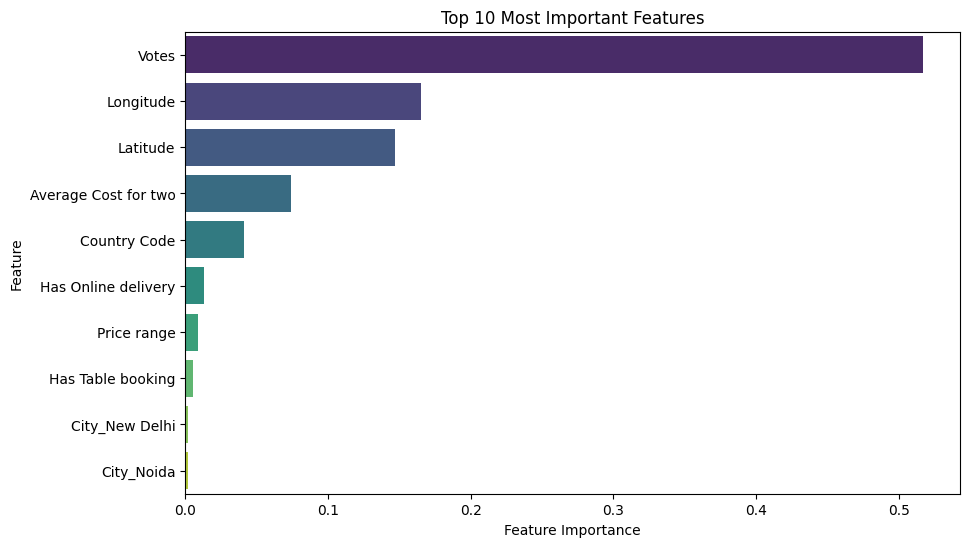

In [112]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### 📌 Feature Importance Observations

- Votes is the most influential feature in the Random Forest model.
- Geographical features such as Longitude and Latitude also contribute significantly to rating predictions.
- Average Cost for Two and Country Code provide additional predictive information.
- Features such as Online Delivery, Price Range, and Table Booking have comparatively lower importance in the current model.
- Feature importance represents predictive contribution and should not be interpreted as a causal relationship.

# 🔄 Cross Validation

To evaluate the stability and generalisation ability of the Random Forest model, 5-fold cross-validation is performed. This evaluates the model across multiple subsets of the training data instead of relying on a single train-test split.

In [113]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² Scores for each fold:", cv_scores)
print("Average R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Scores for each fold: [0.46018734 0.46925681 0.39045057 0.34067503 0.49437166]
Average R² Score: 0.43098828067392725
Standard Deviation: 0.05680547252557904


### 📌 Cross-Validation Observation

The Random Forest model achieved an average 5-fold cross-validation R² score of approximately **0.431**, with a standard deviation of approximately **0.057**.

The cross-validation score is lower than the R² score obtained from the original train-test split, indicating that model performance varies across different subsets of the dataset. Therefore, further model optimisation and hyperparameter tuning will be performed to improve generalisation.

# ⚙️ Hyperparameter Tuning

RandomizedSearchCV is used to search for a better combination of Random Forest hyperparameters and improve the model's generalisation performance.

In [114]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [115]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation R²:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}

Best Cross-Validation R²:
0.5827433755417808


### 📌 Hyperparameter Tuning Result

RandomizedSearchCV identified an improved Random Forest configuration:

- n_estimators: 300
- max_depth: 30
- min_samples_split: 10
- min_samples_leaf: 1
- max_features: sqrt

The best cross-validation R² score obtained during hyperparameter tuning was approximately **0.583**.

The tuned model will now be evaluated on the untouched test dataset to determine whether the improved cross-validation performance generalises to unseen data.

In [116]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("MAE :", tuned_mae)
print("MSE :", tuned_mse)
print("RMSE:", tuned_rmse)
print("R² Score:", tuned_r2)

Tuned Random Forest Results
MAE : 0.2562938717064591
MSE : 0.12596917164507426
RMSE: 0.35492135980393497
R² Score: 0.5931514062330373


In [117]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_rf,
        tuned_mae
    ],
    "RMSE": [
        rmse_rf,
        tuned_rmse
    ],
    "R² Score": [
        r2_rf,
        tuned_r2
    ]
})

tuning_comparison

,Model,MAE,RMSE,R² Score
0,Original Random Forest,0.263507,0.365223,0.569190
1,Tuned Random Forest,0.256294,0.354921,0.593151


### 🏆 Tuned Model Result

Hyperparameter tuning improved the performance of the Random Forest model.

- MAE decreased from approximately **0.264 to 0.256**.
- RMSE decreased from approximately **0.365 to 0.355**.
- R² increased from approximately **0.569 to 0.593**.

Since the tuned Random Forest achieved lower prediction errors and a higher R² score on the unseen test data, it was selected as the final model.

# 📊 Actual vs Predicted Ratings

This visualization compares the actual restaurant ratings with the ratings predicted by the final tuned Random Forest model.

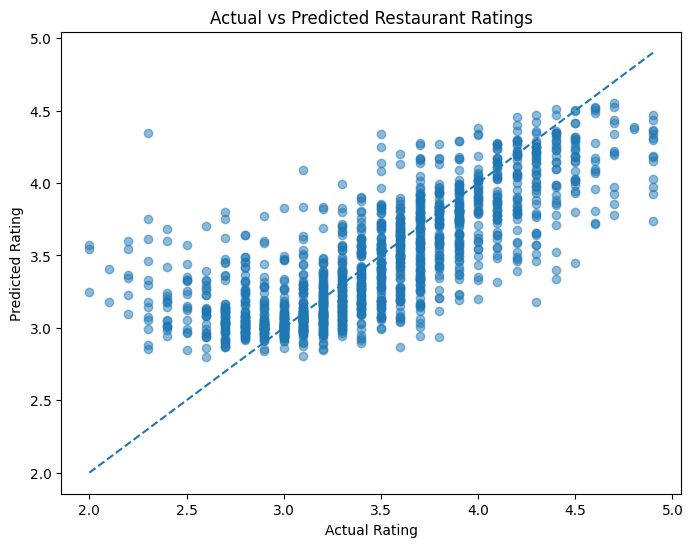

In [118]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.show()

# 💾 Saving the Final Model

The tuned Random Forest model and its expected input feature structure are saved so that the trained model can later be used for real-time predictions in the Streamlit application.

In [119]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(best_rf, "model/restaurant_rating_model.pkl")
joblib.dump(list(X_train.columns), "model/model_features.pkl")

print("Final model saved successfully!")
print("Number of model features:", len(X_train.columns))


Final model saved successfully!
Number of model features: 149


In [120]:
joblib.dump(best_rf, "model/restaurant_rating_model.pkl")
joblib.dump(list(X_train.columns), "model/model_features.pkl")

['model/model_features.pkl']

# 🧪 Custom Restaurant Rating Prediction

A custom restaurant input is passed to the saved model to verify that the trained model can generate predictions outside the training workflow.

In [121]:
import joblib
import pandas as pd

loaded_model = joblib.load("model/restaurant_rating_model.pkl")

loaded_features = joblib.load("model/model_features.pkl")

In [122]:
# Create an empty input with exactly the same features
custom_input = pd.DataFrame(
    0,
    index=[0],
    columns=loaded_features,
    dtype=float
)

# Example restaurant details
custom_input["Country Code"] = 1
custom_input["Longitude"] = 77.2090
custom_input["Latitude"] = 28.6139
custom_input["Average Cost for two"] = 800

custom_input["Has Table booking"] = 1
custom_input["Has Online delivery"] = 1
custom_input["Is delivering now"] = 0
custom_input["Switch to order menu"] = 0

custom_input["Price range"] = 2
custom_input["Votes"] = 500

# One-hot encoded city
city_column = "City_New Delhi"

if city_column in custom_input.columns:
    custom_input[city_column] = 1

# Prediction
predicted_rating = loaded_model.predict(custom_input)[0]

print("Predicted Restaurant Rating:", round(predicted_rating, 2))

Predicted Restaurant Rating: 3.74


In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision :", precision)

NameError: name 'precision_rating' is not defined

### ✅ Custom Prediction Result

The saved model was successfully tested using manually provided restaurant information and predicted a rating of **3.74/5**. This confirms that the trained model can be loaded and used for new restaurant predictions without retraining.